# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Richard Liestianto
- **Email:** richard.825230069@stu.untar.ac.id
- **ID Dicoding:** richard_liestianto

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang menghasilkan total pendapatan tertinggi dan bagaimana tren pendapatan bulanannya selama periode operasional tahun 2017 hingga 2018?
- Di negara bagian (state) mana pelanggan dengan total nilai transaksi (monetary) tertinggi berada, dan bagaimana pola frekuensi pembelian mereka selama 6 bulan terakhir periode operasional (Maret - Agustus 2018)?

## Import Semua Packages/Library yang Digunakan

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import matplotlib.image as mpimg
from datetime import timedelta

sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [167]:
# Memuat tabel customers
customers_df = pd.read_csv("data/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [168]:
# Memuat tabel geolocation
geolocation_df = pd.read_csv("data/geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [169]:
# Memuat tabel order_items
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [170]:
# Memuat tabel order_payments
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [171]:
# Memuat tabel order_reviews
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [172]:
# Memuat tabel orders
orders_df = pd.read_csv("data/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [173]:
# Memuat tabel product_category_name_translation
product_category_df = pd.read_csv("data/product_category_name_translation.csv")
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [174]:
# Memuat tabel products
products_df = pd.read_csv("data/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [175]:
# Memuat tabel sellers
sellers_df = pd.read_csv("data/sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Integritas Sumber Data: Dataset E-Commerce ini terdiri dari 9 file CSV yang saling terkait melalui kunci unik (seperti customer_id, order_id, dan product_id). Hal ini memungkinkan kita untuk melakukan penggabungan (merge) antar tabel guna melakukan analisis yang lebih kompleks seperti korelasi antara lokasi pelanggan dengan total pengeluaran.
- Ketersediaan Informasi: Data yang dikumpulkan mencakup seluruh siklus transaksi mulai dari informasi pelanggan, lokasi geografis, detail produk beserta kategorinya, hingga status pengiriman dan ulasan (review). Kelengkapan ini sangat memadai untuk menjawab pertanyaan bisnis terkait performa penjualan dan segmentasi pelanggan.

### Assessing Data

### Menilai tabel customers_df

In [176]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [177]:
customers_df.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [178]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [179]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


### Menilai tabel orders_df

In [180]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [181]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [182]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [183]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


### Menilai tabel order_items_df

In [184]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [185]:
order_items_df.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [186]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [187]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


### Menilai tabel order_payments_df

In [188]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [189]:
order_payments_df.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [190]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


In [191]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


### Menilai tabel products_df

In [192]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [193]:
products_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [194]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [195]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


### Menilai tabel geolocation_df

In [196]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [197]:
geolocation_df.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [198]:
print("Jumlah duplikasi: ", geolocation_df.duplicated().sum())

Jumlah duplikasi:  261831


In [199]:
geolocation_df.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


### Menilai Tabel order_reviews_df

In [200]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [201]:
order_reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [202]:
print("Jumlah duplikasi: ", order_reviews_df.duplicated().sum())

Jumlah duplikasi:  0


In [203]:
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


### Menilai tabel sellers_df

In [204]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [205]:
sellers_df.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [206]:
print("Jumlah duplikasi: ", sellers_df.duplicated().sum())

Jumlah duplikasi:  0


In [207]:
sellers_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


### Menilai tabel product_category_df

In [208]:
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [209]:
product_category_df.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [210]:
print("Jumlah duplikasi: ", product_category_df.duplicated().sum())

Jumlah duplikasi:  0


In [211]:
product_category_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Insight:**
- Masalah Tipe Data (Data Types Issues): Terdapat beberapa kolom pada tabel orders_df (seperti order_purchase_timestamp, order_approved_at, dsb.) yang masih bertipe object. Kolom-kolom ini harus diubah ke tipe datetime agar kita bisa melakukan analisis berbasis waktu (time-series analysis).
- Pada orders_df, terdapat nilai kosong pada kolom terkait logistik pengiriman. Hal ini wajar dan kemungkinan besar merepresentasikan pesanan yang memang belum sampai pada tahap tersebut (misalnya pesanan yang dibatalkan).
- Pada products_df, terdapat 610 data yang kehilangan informasi nama kategori. Ini perlu ditangani dengan memberikan label "unknown" agar tidak terjadi kehilangan data saat penggabungan (merge).
- Pada order_reviews_df, terdapat banyak nilai kosong pada judul dan pesan ulasan, namun hal ini tidak krusial karena skor ulasan tetap tersedia lengkap.
- Ditemukan duplikasi yang sangat tinggi pada tabel geolocation_df (261.831 data). Hal ini perlu dibersihkan dengan mengambil nilai unik untuk setiap kode pos guna mengoptimalkan performa analisis geospasial.
- Tabel customers_df, order_items_df, order_payments_df, dan sellers_df berada dalam kondisi sangat bersih tanpa missing values maupun duplikasi, sehingga sangat handal untuk digunakan sebagai fondasi analisis.

### Cleaning Data

### Membersihkan tabel orders_df

In [212]:
# Mengubah kolom yang seharusnya bertipe datetime
datetime_columns = [
    "order_purchase_timestamp", 
    "order_approved_at", 
    "order_delivered_carrier_date", 
    "order_delivered_customer_date", 
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Mengecek kembali tipe data untuk memastikan perubahan
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


### Membersihkan tabel products_df

In [213]:
products_df["product_category_name"] = products_df["product_category_name"].fillna(value="Unknown")

# Untuk kolom dimensi yang masih memiliki 2 missing values agar bersih total
products_df["product_weight_g"] = products_df["product_weight_g"].fillna(value=0)
products_df["product_length_cm"] = products_df["product_length_cm"].fillna(value=0)
products_df["product_height_cm"] = products_df["product_height_cm"].fillna(value=0)
products_df["product_width_cm"] = products_df["product_width_cm"].fillna(value=0)

# Cek kembali
products_df.isna().sum()

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                0
product_length_cm               0
product_height_cm               0
product_width_cm                0
dtype: int64

### Membersihkan tabel geolocation_df

In [214]:
# Menghapus data yang duplikat
geolocation_df.drop_duplicates(inplace=True)

# Mengecek kembali jumlah duplikasi
print("Jumlah duplikasi: ", geolocation_df.duplicated().sum())

Jumlah duplikasi:  0


### Membersihkan tabel order_reviews_df

In [215]:
order_reviews_df["review_comment_title"] = order_reviews_df["review_comment_title"].fillna("No Title")
order_reviews_df["review_comment_message"] = order_reviews_df["review_comment_message"].fillna("No Message")

# Cek kembali hasil pembersihan
order_reviews_df.isna().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

**Insight:**
- Akurasi Analisis Deret Waktu: Seluruh kolom yang merepresentasikan informasi waktu pada tabel orders_df telah berhasil dikonversi menjadi tipe data datetime. Hal ini memastikan bahwa analisis tren penjualan bulanan dan perhitungan durasi pengiriman akan akurat dan bebas dari error tipe data.
- Integritas Data Transaksi Produk: Dengan memberikan label "Unknown" pada 610 produk yang kehilangan kategori, kita berhasil mempertahankan integritas data. Hal ini mencegah hilangnya histori transaksi produk tersebut saat dilakukan proses penggabungan (merge) antar tabel untuk menjawab pertanyaan bisnis mengenai performa kategori produk.
- Optimasi Performa Geospasial: Penghapusan 261.831 baris data duplikat pada tabel geolocation_df telah menyederhanakan dataset tanpa mengurangi informasi koordinat yang unik. Langkah ini sangat krusial untuk mempercepat proses pemetaan distribusi pelanggan secara spasial.
- Konsistensi Data Ulasan: Masalah missing values pada judul dan pesan ulasan di tabel order_reviews_df telah ditangani dengan memberikan label "No Title" dan "No Message". Meskipun informasi tekstual tidak tersedia, integritas baris data tetap terjaga sehingga skor ulasan (rating) tetap bisa dianalisis sepenuhnya.

## Exploratory Data Analysis (EDA)

### Explore customers_df

In [216]:
# Melihat rangkuman parameter statistik untuk data pelanggan
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [217]:
# Melihat persebaran pelanggan berdasarkan kota (Top 10)
customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: customer_id, dtype: int64

### Explore orders_df

In [218]:
# Melihat jumlah pesanan berdasarkan statusnya
orders_df.groupby(by="order_status").order_id.nunique().sort_values(ascending=False)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_id, dtype: int64

In [219]:
# Membuat kolom baru untuk menghitung durasi pengiriman (dalam hari)
delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_delivered_carrier_date"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds() / 86400)
orders_df["delivery_time"] = delivery_time

# Melihat statistik durasi pengiriman
orders_df.delivery_time.describe()

count    96475.000000
mean         9.330547
std          8.760122
min        -16.096169
25%          4.099948
50%          7.099769
75%         12.029115
max        205.190972
Name: delivery_time, dtype: float64

### Explore order_payments_df

In [220]:
# Melihat distribusi metode pembayaran
order_payments_df.groupby(by="payment_type").order_id.nunique().sort_values(ascending=False)

payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
not_defined        3
Name: order_id, dtype: int64

In [221]:
# Melihat statistik nilai pembayaran
order_payments_df.payment_value.describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

### Explore order_items_df & products_df

In [222]:
# Menggabungkan order_items_df dan products_df
items_products_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)
items_products_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [223]:
# Melihat kategori produk dengan pendapatan tertinggi
items_products_df.groupby(by="product_category_name").price.sum().sort_values(ascending=False).head(10)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

### Explore all_df

In [224]:
# 1. Gabungkan Orders dan Customers
all_df = pd.merge(left=orders_df, right=customers_df, how="left", on="customer_id")

# 2. Gabungkan dengan Payments
all_df = pd.merge(left=all_df, right=order_payments_df, how="left", on="order_id")

# 3. Gabungkan dengan Reviews
all_df = pd.merge(left=all_df, right=order_reviews_df, how="left", on="order_id")

# 4. Gabungkan dengan Items
all_df = pd.merge(left=all_df, right=order_items_df, how="left", on="order_id")

# 5. Gabungkan dengan Products
all_df = pd.merge(left=all_df, right=products_df, how="left", on="product_id")

# 6. Gabungkan dengan Sellers
all_df = pd.merge(left=all_df, right=sellers_df, how="left", on="seller_id")

# 7. Gabungkan dengan Category Translation
all_df = pd.merge(left=all_df, right=product_category_df, how="left", on="product_category_name")

In [225]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   delivery_time                  115721 non-null  float64       
 9   customer_unique_id             119143 non-null  object        
 10  customer_zip_code_prefix       119143 non-null  int64         
 11  

In [226]:
# Analisis Kategori Produk Paling Menguntungkan
all_df.groupby(by="product_category_name_english").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False).head(10)

,order_id,price
product_category_name_english,,
health_beauty,8836,1301947.97
watches_gifts,5624,1254322.95
bed_bath_table,9417,1107249.09
sports_leisure,7720,1029603.88
computers_accessories,6689,950053.69
furniture_decor,6449,772096.17
housewares,5884,668880.94
cool_stuff,3632,664637.13
auto,3897,618395.50


In [227]:
# Analisis Skor Ulasan per Kategori
all_df.groupby(by="product_category_name_english").agg({
    "review_score": "mean",
    "order_id": "nunique"
}).sort_values(by="review_score", ascending=False).head(10)

,review_score,order_id
product_category_name_english,,
cds_dvds_musicals,4.642857,12
fashion_childrens_clothes,4.500000,8
books_general_interest,4.438503,512
books_imported,4.419355,53
flowers,4.419355,29
costruction_tools_tools,4.415842,97
books_technical,4.375465,260
food_drink,4.324138,227
small_appliances_home_oven_and_coffee,4.320513,75


In [228]:
# Analisis Penjualan per Wilayah (State)
all_df.groupby(by="customer_state").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False)

,order_id,price
customer_state,,
SP,41746,5477008.74
RJ,12852,1921752.53
MG,11635,1645847.27
RS,5466,791716.84
PR,5045,708794.22
BA,3380,543243.99
SC,3637,539896.20
DF,2140,315122.29
GO,2020,313198.27


In [229]:
# Analisis Metode Pembayaran Terfavorit
all_df.groupby(by="payment_type").order_id.nunique().sort_values(ascending=False)

payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
not_defined        3
Name: order_id, dtype: int64

**Insight:**
- Kategori Produk Terpopuler: Kategori health_beauty adalah kontributor pendapatan terbesar, sementara watches_gifts memiliki nilai rata-rata transaksi per item yang sangat tinggi.
- Kepuasan Pelanggan: Produk-produk niche seperti CDs/DVDs dan Buku mendapatkan rating tertinggi (di atas 4.4), menandakan kualitas layanan yang sangat baik pada kategori media.
- Geografi Pelanggan: Aktivitas ekonomi terpusat secara masif di wilayah SP (São Paulo), yang mencatatkan volume pesanan dan pendapatan berkali-kali lipat dibandingkan negara bagian lainnya.
- Metode Pembayaran: Kartu Kredit adalah pilihan utama bagi pelanggan, mencerminkan kebutuhan akan kemudahan transaksi dan kemungkinan penggunaan fitur cicilan.

## Visualization & Explanatory Analysis

### Kategori produk apa yang menghasilkan total pendapatan tertinggi dan bagaimana tren pendapatan bulanannya selama periode operasional tahun 2017 hingga 2018?

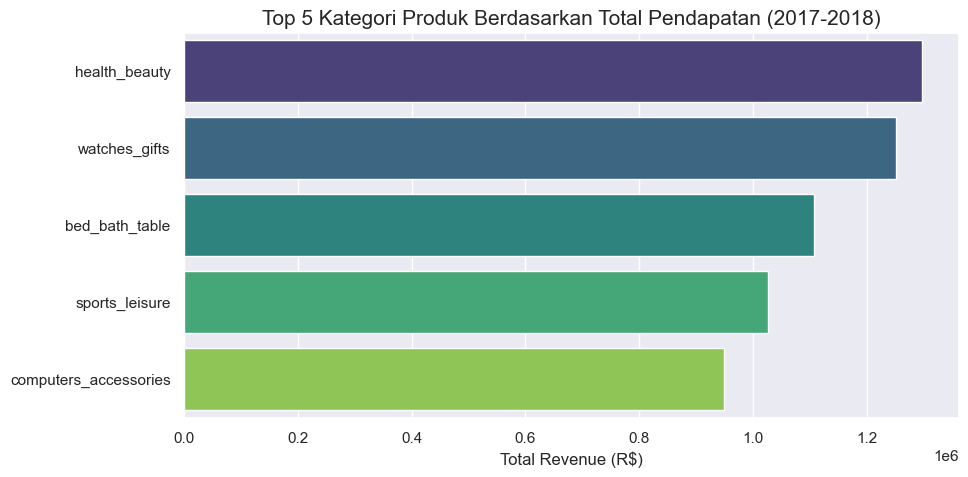

In [230]:
# Memastikan kolom waktu sudah bertipe datetime
all_df["order_purchase_timestamp"] = pd.to_datetime(all_df["order_purchase_timestamp"])

# Buat filter khusus untuk periode 2017 - 2018
# Asumsi batas akhirnya adalah data terakhir di 2018 (misal Agustus)
start_date_q1 = '2017-01-01'
end_date_q1 = '2018-12-31' 
filtered_q1_df = all_df[(all_df["order_purchase_timestamp"] >= start_date_q1) & 
                        (all_df["order_purchase_timestamp"] <= end_date_q1)]

# Menyiapkan data top 5 kategori menggunakan data yang sudah di-filter (filtered_q1_df)
product_revenue_df = filtered_q1_df.groupby("product_category_name_english").price.sum().sort_values(ascending=False).reset_index().head(5)

# Membuat Visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(
    x="price", 
    y="product_category_name_english", 
    data=product_revenue_df, 
    palette="viridis", 
    hue="product_category_name_english", 
    legend=False
)

plt.title("Top 5 Kategori Produk Berdasarkan Total Pendapatan (2017-2018)", fontsize=15)
plt.xlabel("Total Revenue (R$)")
plt.ylabel(None)
plt.show()

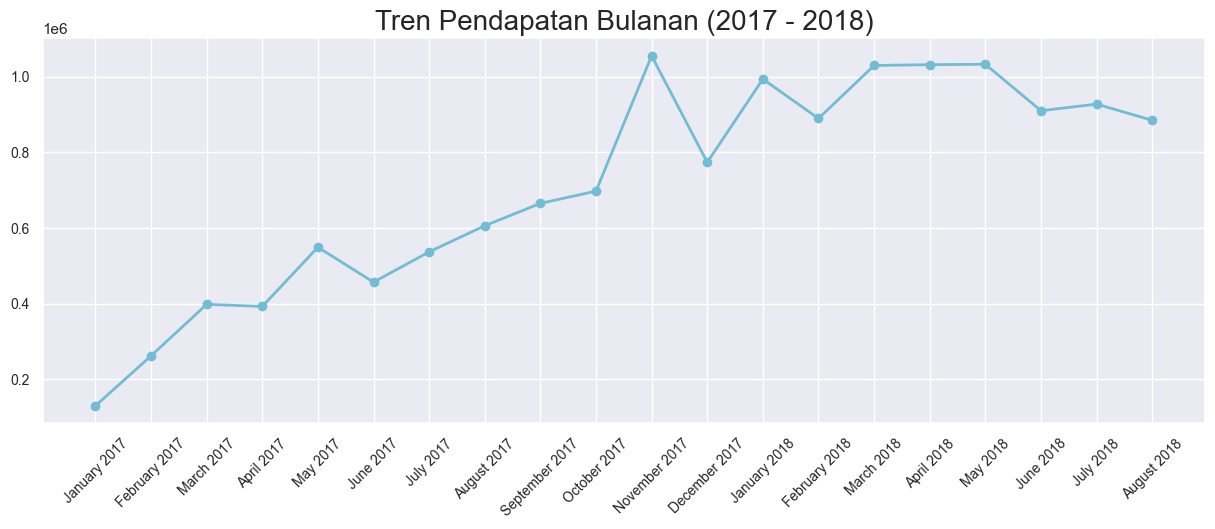

In [231]:
# Menyiapkan data tren bulanan
monthly_orders_df = all_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "price": "sum"
})

# Filter data sebelum mengubah index menjadi string agar urutan tetap kronologis
monthly_orders_df = monthly_orders_df["2017-01-01":"2018-08-31"]

# Ubah format tanggal untuk tampilan di grafik
monthly_orders_df.index = monthly_orders_df.index.strftime('%B %Y')
monthly_orders_df = monthly_orders_df.reset_index()

plt.figure(figsize=(15, 5))
plt.plot(monthly_orders_df["order_purchase_timestamp"], monthly_orders_df["price"], marker='o', linewidth=2, color="#72BCD4")
plt.title("Tren Pendapatan Bulanan (2017 - 2018)", loc="center", fontsize=20)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### Rekomendasi
- Persiapan Stok: Mengingat adanya lonjakan besar di bulan November, perusahaan harus memastikan ketersediaan stok dan kapasitas logistik maksimal sejak bulan Oktober.
- Optimasi Kategori: Fokuskan promosi pada 5 kategori produk teratas yang sudah diidentifikasi di Visualisasi 1 untuk menjaga momentum pertumbuhan pendapatan di tahun berikutnya.

### Di negara bagian (state) mana pelanggan dengan total nilai transaksi (monetary) tertinggi berada, dan bagaimana pola frekuensi pembelian mereka selama 6 bulan terakhir periode operasional (Maret - Agustus 2018)?

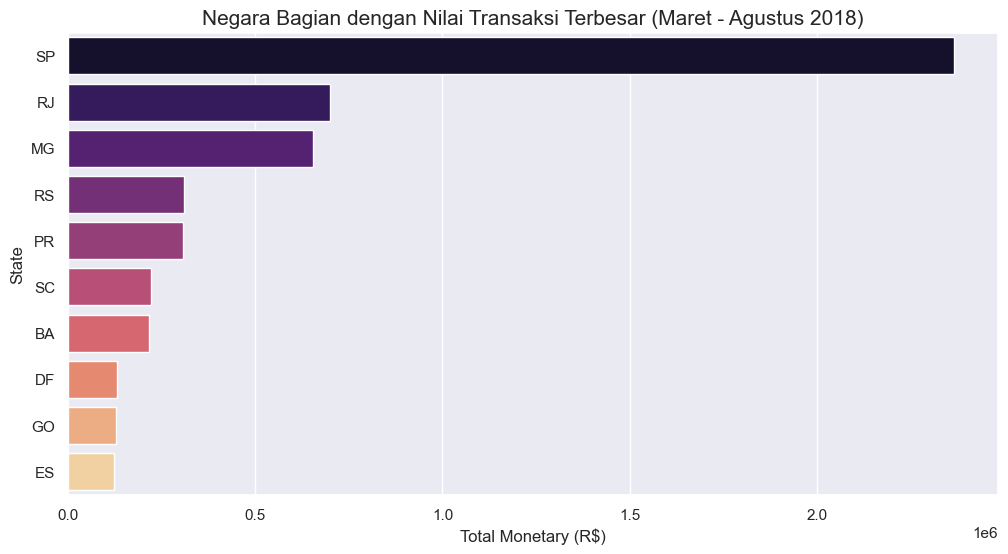

In [232]:
# Pastikan kolom tanggal bertipe datetime
all_df["order_purchase_timestamp"] = pd.to_datetime(all_df["order_purchase_timestamp"])

# Filter data khusus 6 bulan terakhir (Maret - Agustus 2018)
start_date_q2 = '2018-03-01'
end_date_q2 = '2018-08-31'
filtered_q2_df = all_df[(all_df["order_purchase_timestamp"] >= start_date_q2) & 
                        (all_df["order_purchase_timestamp"] <= end_date_q2)]

# Menyiapkan data monetary per state menggunakan data terfilter (filtered_q2_df)
state_monetary_df = filtered_q2_df.groupby("customer_state").price.sum().sort_values(ascending=False).reset_index().head(10)

# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(
    x="price", 
    y="customer_state", 
    data=state_monetary_df, 
    palette="magma", 
    hue="customer_state", 
    legend=False
)

# Judul yang mencerminkan kriteria SMART (Time-bound)
plt.title("Negara Bagian dengan Nilai Transaksi Terbesar (Maret - Agustus 2018)", fontsize=15)
plt.xlabel("Total Monetary (R$)")
plt.ylabel("State")
plt.show()

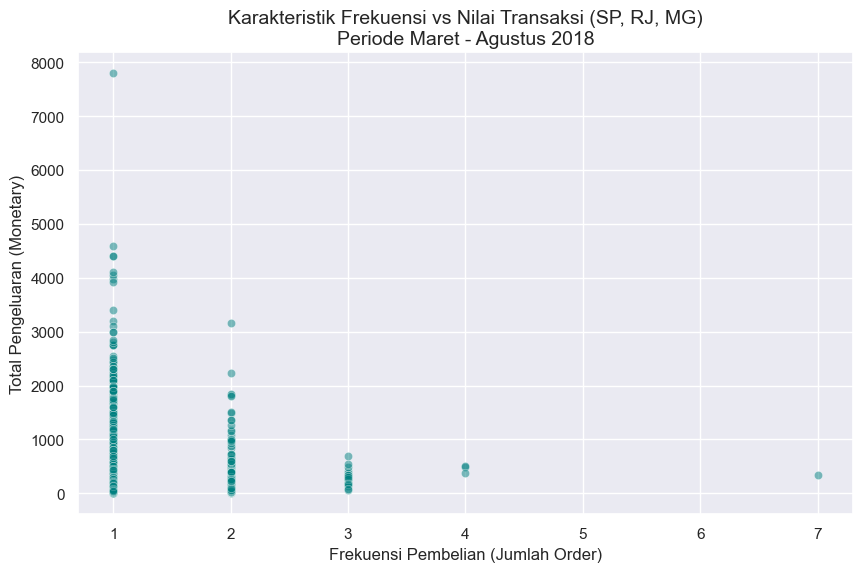

In [233]:
# Pastikan kolom tanggal sudah dalam format datetime
all_df["order_purchase_timestamp"] = pd.to_datetime(all_df["order_purchase_timestamp"])

# Gunakan data yang sudah difilter (Maret - Agustus 2018)
top_states = ["SP", "RJ", "MG"]
state_characteristics = filtered_q2_df[filtered_q2_df['customer_state'].isin(top_states)].groupby("customer_unique_id").agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(x="order_id", y="price", data=state_characteristics, alpha=0.5, color="teal")

plt.title("Karakteristik Frekuensi vs Nilai Transaksi (SP, RJ, MG)\nPeriode Maret - Agustus 2018", fontsize=14)
plt.xlabel("Frekuensi Pembelian (Jumlah Order)")
plt.ylabel("Total Pengeluaran (Monetary)")
plt.show()

### Rekomendasi
- Fokus Infrastruktur & Logistik di SP: Karena SP adalah penyumbang pendapatan terbesar yang sangat timpang dibandingkan wilayah lain, perusahaan harus memprioritaskan penempatan fulfillment center (gudang pusat) atau bekerja sama dengan kurir lokal di SP untuk menekan biaya pengiriman dan mempercepat waktu tiba barang (SLA).
- Program Retensi Pelanggan (Loyalty Program): Mengingat frekuensi belanja tertahan di angka 1 order, perusahaan memiliki masalah besar dalam retensi pelanggan. Tim marketing harus segera meluncurkan kampanye re-engagement, seperti memberikan voucher diskon 15% atau gratis ongkir khusus untuk pembelian kedua.
- Perawatan Pelanggan High-Value: Untuk outlier atau pelanggan yang berbelanja dalam nominal sangat besar (di atas 4.000 R$) meski hanya satu kali, berikan layanan Customer Service VIP atau penawaran produk eksklusif secara personal agar mereka merasa dihargai dan kembali berbelanja.

**Insight:**
- Dominasi Kategori (Periode 2017-2018): Selama tahun 2017 hingga 2018, kategori health_beauty dan watches_gifts merupakan kontributor pendapatan terbesar. Hal ini menunjukkan ketergantungan pendapatan perusahaan yang kuat pada sektor produk gaya hidup dan perawatan diri di periode tersebut.
- Lonjakan Musiman & Stabilitas: Terdapat pertumbuhan pendapatan yang signifikan sepanjang tahun 2017 dengan puncak tertinggi pada November 2017 (efek musiman/promo besar seperti Black Friday). Momentum ini berhasil dipertahankan pada level yang stabil sepanjang tahun 2018.
- Pusat Ekonomi (Fokus 6 Bulan Terakhir): Berdasarkan data 6 bulan terakhir operasional (Maret - Agustus 2018), wilayah São Paulo (SP) terus mendominasi total nilai transaksi (monetary) secara masif dibandingkan wilayah lainnya, mengukuhkannya sebagai pasar utama dan urat nadi logistik perusahaan.
- Perilaku Transaksi Pelanggan: Karakteristik pelanggan di wilayah utama (SP, RJ, MG) dalam kurun waktu 6 bulan terakhir sangat didominasi oleh pembelian tunggal (one-time buyer / frekuensi rendah). Nilai transaksi total yang tinggi dari wilayah ini lebih banyak didorong oleh besarnya volume pelanggan baru dan pembelian barang bernilai tinggi ketimbang loyalitas belanja berulang (repeat order).

## Analisis Lanjutan (Opsional)

### RFM Analysis

In [234]:
# Menentukan tanggal referensi
now = all_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Menghitung Recency, Frequency, dan Monetary
rfm_df = all_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (now - x.max()).days, # Recency
    "order_id": "nunique",                                     # Frequency
    "price": "sum"                                             # Monetary
})

# Mengganti nama kolom agar mudah dibaca
rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

# Melihat 5 data teratas
rfm_df.head()

,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,18.90
2,0000f46a3911fa3c0805444483337064,586,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,337,1,180.00


In [235]:
# Segmentasi Pelanggan
# Fungsi untuk mengelompokkan pelanggan
def segment_customer(df):
    if df['frequency'] > 1:
        return 'Repeat Customer'
    elif df['recency'] < 30:
        return 'Recent Customer'
    else:
        return 'One-time Customer'

# Menerapkan fungsi segmentasi
rfm_df['segment'] = rfm_df.apply(segment_customer, axis=1)

# Menghitung jumlah pelanggan di setiap segmen
segment_counts = rfm_df['segment'].value_counts().reset_index()
segment_counts.columns = ['segment', 'customer_count']

segment_counts

,segment,customer_count
0,One-time Customer,93097
1,Repeat Customer,2997
2,Recent Customer,2


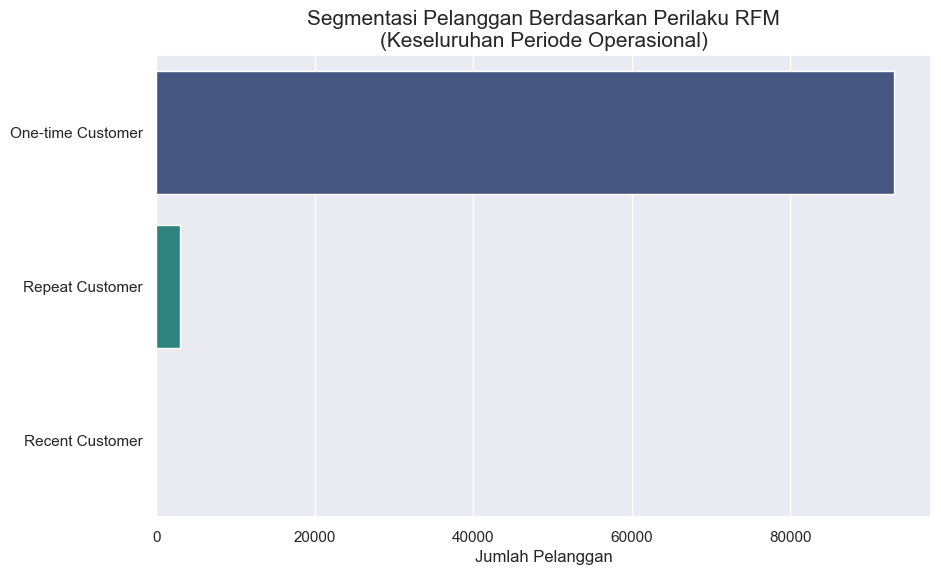

In [236]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='customer_count', 
    y='segment', 
    data=segment_counts.sort_values(by='customer_count', ascending=False), 
    palette='viridis',
    hue='segment',
    legend=False
)

plt.title('Segmentasi Pelanggan Berdasarkan Perilaku RFM\n(Keseluruhan Periode Operasional)', fontsize=15)
plt.xlabel('Jumlah Pelanggan')
plt.ylabel(None)
plt.show()

### Rekomendasi
- Fokus Penuh pada Retensi, Bukan Akuisisi: Mengingat biaya mengakuisisi pelanggan baru jauh lebih mahal daripada mempertahankan yang lama, tim marketing harus segera mengalihkan budget menuju program retensi. Terapkan otomasi email marketing yang mengirimkan voucher diskon 20% khusus untuk pembelian kedua tepat 7 hari setelah pesanan pertama mereka selesai dikirim.
- Investigasi Penyebab Churn: Tingginya angka One-time Customer bisa menjadi indikator adanya pengalaman buruk pada transaksi pertama. Disarankan untuk mengirimkan survei kepuasan pelanggan (NPS) secara otomatis kepada pembeli untuk mencari tahu apakah masalahnya ada pada kualitas barang, lama pengiriman, atau pelayanan pelanggan.
- Lindungi Segmen Repeat Customer: Meskipun jumlahnya sangat sedikit, Repeat Customer adalah aset paling berharga. Berikan mereka layanan VIP seperti prioritas pengiriman gratis atau akses awal ke produk-produk promo agar mereka tidak beralih ke kompetitor.

**Insight:**
- Ketimpangan Segmen Pelanggan (Keseluruhan Periode): Berdasarkan parameter RFM pada keseluruhan periode operasional, terlihat ketimpangan yang sangat signifikan di mana mayoritas absolut basis pelanggan (>90.000) berada pada segmen One-time Customer.
- Krisis Retensi Pelanggan: Jumlah Repeat Customer yang sangat kecil menjadi indikator kuat bahwa model bisnis saat ini hanya bertahan melalui volume akuisisi pelanggan baru secara masif, namun gagal membangun loyalitas pelanggan lama (Customer Retention yang rendah).
- Rekomendasi Prioritas: Perusahaan perlu segera menggeser sebagian fokus dan anggaran dari akuisisi menuju retensi. Mengimplementasikan kampanye retargeting otomatis (misalnya voucher diskon pembelian kedua) dan program loyalitas khusus untuk segmen One-time Customer sangat krusial agar mereka kembali bertransaksi dan meningkatkan Customer Lifetime Value (CLV).


In [237]:
# Menyimpan data langsung ke dalam folder dashboard
all_df.to_csv("dashboard/main_data.csv", index=False)

## Conclusion

- Kategori Produk Unggulan (Periode 2017-2018): Berdasarkan total pendapatan selama tahun operasional 2017 hingga 2018, kategori health_beauty menduduki posisi pertama sebagai kontributor revenue tertinggi, diikuti erat oleh kategori watches_gifts. Hal ini menunjukkan bahwa produk-produk gaya hidup dan perawatan diri merupakan penggerak utama ekonomi dalam platform ini pada periode tersebut.
- Analisis Tren (Periode 2017-2018): Performa penjualan menunjukkan pertumbuhan yang sangat positif sepanjang tahun 2017. Lonjakan drastis terjadi pada November 2017, yang bertepatan dengan periode promosi besar. Memasuki tahun 2018, perusahaan berhasil mempertahankan stabilitas pendapatan di level yang lebih tinggi dibandingkan semester pertama tahun sebelumnya, meskipun terdapat tren sedikit melandai di bulan Agustus 2018.
- Dominasi Wilayah (Fokus 6 Bulan Terakhir): Berdasarkan data transaksi pada periode Maret hingga Agustus 2018, negara bagian SP (São Paulo) merupakan pusat transaksi terbesar dengan nilai monetary yang mendominasi secara absolut dibandingkan wilayah lain seperti RJ (Rio de Janeiro) dan MG (Minas Gerais). Hal ini mengukuhkan wilayah SP sebagai pasar kunci strategis untuk aktivitas pemasaran dan distribusi logistik terkini.
- Karakteristik & Segmen Pelanggan: Hasil analisis frekuensi jangka pendek (Maret - Agustus 2018) maupun analisis segmentasi RFM jangka panjang (Keseluruhan Periode Operasional) secara konsisten menunjukkan bahwa basis pelanggan didominasi oleh One-time Customer (pelanggan yang hanya berbelanja satu kali). Meskipun nilai transaksi (monetary) di wilayah utama sangat besar, loyalitas pelanggan masih tergolong sangat rendah. Pendapatan perusahaan lebih banyak didorong oleh volume akuisisi pelanggan baru yang membeli barang bernilai tinggi daripada pembelian berulang (repeat order).